# 1. Set up

In [ ]:
# Import Library

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from tqdm import tqdm

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Seed & Device

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [ ]:
# Check Device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# 2. Load Data

In [ ]:
##### Copy from Google Drive

!cp -r "/content/drive/MyDrive/Colab Notebooks/MPA_MLF/Final_Project/x_train" /content/
!cp -r "/content/drive/MyDrive/Colab Notebooks/MPA_MLF/Final_Project/x_test" /content/
!cp "/content/drive/MyDrive/Colab Notebooks/MPA_MLF/Final_Project/y_train_v2.csv" /content/
!cp "/content/drive/MyDrive/Colab Notebooks/MPA_MLF/Final_Project/y_test_submission_example_v2.csv" /content/


# Set Path
TRAIN_CSV = "/content/y_train_v2.csv"
TEST_CSV = "/content/y_test_submission_example_v2.csv"
TRAIN_DIR = "/content/x_train"
TEST_DIR = "/content/x_test"

# Load CSV
train_df = pd.read_csv(TRAIN_CSV)

# Create test_df from filenames
files = sorted(os.listdir(TEST_DIR))
ids = [int(f.split("_")[1].replace(".png","")) - 1 for f in files]

test_df = pd.DataFrame({"id": ids}).sort_values("id").reset_index(drop=True)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (9227, 2)
Test: (3955, 1)


# 3. Data Exploration

   id  target
0   0       0
1   1       1
2   2       0
3   3       2
4   4       2
target
0    1462
1    3786
2    3002
3     977
Name: count, dtype: int64


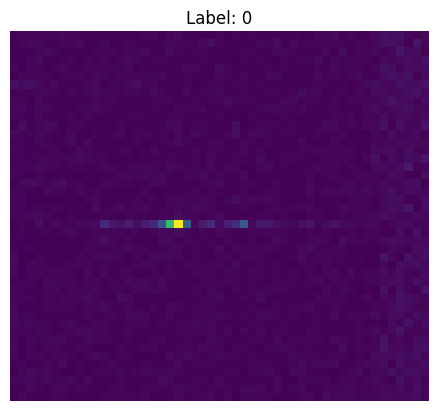

In [ ]:
print(train_df.head())
print(train_df["target"].value_counts().sort_index())

# Sample visualization
sample = train_df.iloc[0]
img_path = os.path.join(TRAIN_DIR, f"img_{sample['id']+1}.png")

img = Image.open(img_path)
plt.imshow(img)
plt.title(f"Label: {sample['target']}")
plt.axis("off")
plt.show()

# 4. Transforms

In [ ]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# 5. Dataset & DataLoader

In [ ]:
class OccupancyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_number = int(row["id"]) + 1
        img_path = os.path.join(self.img_dir, f"img_{img_number}.png")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if "target" in self.df.columns:
            label = int(row["target"])
            return image, label
        else:
            return image, int(row["id"])

# 6. Model & Loss

In [ ]:
def get_model():
    model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 4)
    return model.to(device)

# Weighted loss
class_counts = train_df["target"].value_counts().sort_index().values
weights = 1.0 / class_counts
weights = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

In [ ]:
def get_model_efficient():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)
    return model.to(device)

# 7. K-Fold Training

In [ ]:
BATCH_SIZE = 64
EPOCHS = 10
LR = 3e-4
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

best_model_paths = []
fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(train_df["id"], train_df["target"])):

    print(f"\n===== Fold {fold+1} =====")

    train_fold = train_df.iloc[train_idx]
    valid_fold = train_df.iloc[valid_idx]

    train_ds = OccupancyDataset(train_fold, TRAIN_DIR, train_transform)
    valid_ds = OccupancyDataset(valid_fold, TRAIN_DIR, valid_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = get_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc = 0
    path = f"best_model_fold_{fold}.pth"

    for epoch in range(EPOCHS):
        # ===== TRAIN =====
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # ===== VALID =====
        model.eval()
        preds, labels = [], []

        with torch.no_grad():
            for x, y in valid_loader:
                x = x.to(device)
                out = model(x)

                preds.extend(out.argmax(1).cpu().numpy())
                labels.extend(y.numpy())

        acc = accuracy_score(labels, preds)

        scheduler.step()

        print(f"Fold {fold+1} | Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | Acc: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), path)
            print(f"  → Best updated: {best_acc:.4f}")

    fold_scores.append(best_acc)
    best_model_paths.append(path)

    print(f"Fold {fold+1} Best Acc: {best_acc:.4f}")

    del model
    torch.cuda.empty_cache()

print("\nFold scores:", fold_scores)
print("Mean CV Accuracy:", np.mean(fold_scores))
print("Best model paths:", best_model_paths)

test_ds = OccupancyDataset(test_df, TEST_DIR, valid_transform)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test samples:", len(test_ds))

from tqdm import tqdm

def predict_with_tta(model, loader, device):
    model.eval()
    probs_list = []

    with torch.no_grad():
        for images, _ in tqdm(loader, desc="TTA Predict"):
            images = images.to(device)

            # 원본
            outputs1 = model(images)

            # 좌우 flip
            flipped = torch.flip(images, dims=[3])
            outputs2 = model(flipped)

            outputs = (outputs1 + outputs2) / 2.0
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            probs_list.append(probs)

    return np.concatenate(probs_list, axis=0)

all_fold_probs = []

for fold, model_path in enumerate(best_model_paths):
    print(f"\nLoading model: {model_path}")

    model = get_model()
    model.load_state_dict(torch.load(model_path, map_location=device))

    fold_probs = predict_with_tta(model, test_loader, device)
    all_fold_probs.append(fold_probs)

    del model
    torch.cuda.empty_cache()

resnet_probs = np.mean(all_fold_probs, axis=0)
print("ResNet probs shape:", resnet_probs.shape)


===== Fold 1 =====
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 122MB/s]


Fold 1 | Epoch 1/10 | Loss: 53.2690 | Acc: 0.8478
  → Best updated: 0.8478
Fold 1 | Epoch 2/10 | Loss: 24.9585 | Acc: 0.9166
  → Best updated: 0.9166
Fold 1 | Epoch 3/10 | Loss: 15.4704 | Acc: 0.9052
Fold 1 | Epoch 4/10 | Loss: 11.9765 | Acc: 0.9345
  → Best updated: 0.9345
Fold 1 | Epoch 5/10 | Loss: 6.4945 | Acc: 0.9534
  → Best updated: 0.9534
Fold 1 | Epoch 6/10 | Loss: 3.3412 | Acc: 0.9637
  → Best updated: 0.9637
Fold 1 | Epoch 7/10 | Loss: 0.9974 | Acc: 0.9491
Fold 1 | Epoch 8/10 | Loss: 0.6171 | Acc: 0.9686
  → Best updated: 0.9686
Fold 1 | Epoch 9/10 | Loss: 0.1469 | Acc: 0.9707
  → Best updated: 0.9707
Fold 1 | Epoch 10/10 | Loss: 0.1312 | Acc: 0.9707
Fold 1 Best Acc: 0.9707

===== Fold 2 =====
Fold 2 | Epoch 1/10 | Loss: 51.6383 | Acc: 0.8207
  → Best updated: 0.8207
Fold 2 | Epoch 2/10 | Loss: 25.3333 | Acc: 0.8911
  → Best updated: 0.8911
Fold 2 | Epoch 3/10 | Loss: 16.5887 | Acc: 0.9225
  → Best updated: 0.9225
Fold 2 | Epoch 4/10 | Loss: 11.9348 | Acc: 0.9372
  → Best up

TTA Predict: 100%|██████████| 62/62 [00:20<00:00,  2.97it/s]



Loading model: best_model_fold_1.pth


...


Loading model: best_model_fold_3.pth


TTA Predict: 100%|██████████| 62/62 [00:21<00:00,  2.93it/s]



Loading model: best_model_fold_4.pth


TTA Predict: 100%|██████████| 62/62 [00:21<00:00,  2.92it/s]

ResNet probs shape: (3955, 4)


# 8. Inference

In [ ]:
test_ds = OccupancyDataset(test_df, TEST_DIR, valid_transform)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

all_probs = []

for path in best_model_paths:
    model = get_model()
    model.load_state_dict(torch.load(path))
    model.eval()

    probs = []

    with torch.no_grad():
        for x, _ in tqdm(test_loader):
            x = x.to(device)
            out = model(x)
            probs.append(torch.softmax(out, dim=1).cpu().numpy())

    all_probs.append(np.concatenate(probs))

mean_probs = np.mean(all_probs, axis=0)
preds = np.argmax(mean_probs, axis=1)

100%|██████████| 62/62 [00:14<00:00,  4.35it/s]


# 9. Submission

In [ ]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "target": preds
})

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")

# Validation Check
print(submission.shape)
print(submission.head())

assert len(submission) == 3955
assert submission["id"].nunique() == 3955
assert set(submission["target"].unique()).issubset({0,1,2,3})

print("Submission OK")

Saved submission.csv
(3955, 2)
     id  target
0  9227       2
1  9228       2
2  9229       0
3  9230       0
4  9231       1
Submission OK


In [ ]:
assert len(submission) == 3955
assert submission["id"].nunique() == 3955
assert submission["id"].min() == 9227
assert submission["id"].max() == 13181
assert set(submission["target"].unique()).issubset({0, 1, 2, 3})

print("Submission format looks correct.")

Submission format looks correct.
